In [1]:
# Colab + local compatible loader
import os
import pandas as pd
import numpy as np

CANDIDATES = ['Salary_dataset.csv', 'lab04/Salary_dataset.csv', '/content/Salary_dataset.csv']
path = next((x for x in CANDIDATES if os.path.exists(x)), None)
print('Using:', path)
assert path is not None, 'Salary_dataset.csv not found - upload it in Colab Files panel'
df = pd.read_csv(path)
df.head()


Using: Salary_dataset.csv


,YearsExperience,Salary
0,1.2,39344
1,1.4,46206
2,1.6,37732
3,2.1,43526
4,2.3,39892


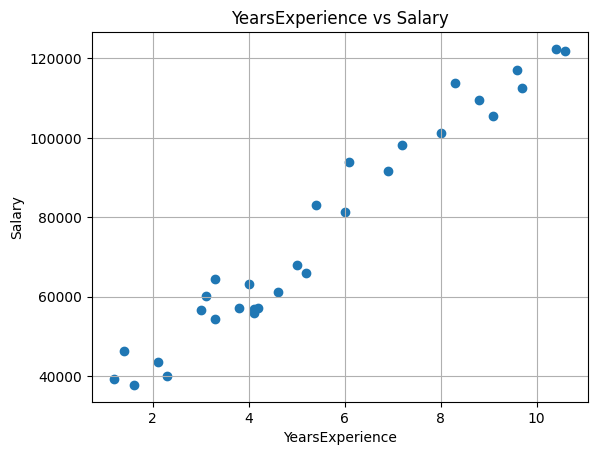

In [2]:
import matplotlib.pyplot as plt
plt.scatter(
    df["YearsExperience"],
    df["Salary"]
)
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.grid("true")
plt.title("YearsExperience vs Salary")

plt.show()

In [3]:
from sklearn.model_selection import train_test_split
X=df[['YearsExperience']]
y=df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
X_test


,YearsExperience
27,9.7
15,5.0
23,8.3
17,5.4
8,3.3
9,3.8


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9423.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.438e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [7]:
y_predict = model.predict(X_test)
y_predict

array([115791.21011287,  71499.27809463, 102597.86866063,  75268.80422384,
        55478.79204548,  60190.69970699])

In [8]:
results = pd.DataFrame({
    'YearsExperience': X_test['YearsExperience'].values,
    'Actual Salary': y_test.values,
    'Predicted Salary': y_predict
})
print(results)

   YearsExperience  Actual Salary  Predicted Salary
0              9.7         112636     115791.210113
1              5.0          67939      71499.278095
2              8.3         113813     102597.868661
3              5.4          83089      75268.804224
4              3.3          64446      55478.792045
5              3.8          57190      60190.699707


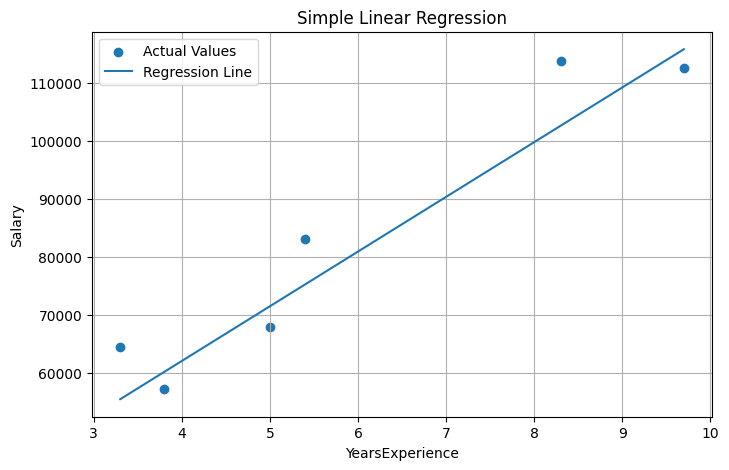

In [9]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test["YearsExperience"],
    y_test,
    label="Actual Values"
)

sorted_indices = np.argsort(X_test["YearsExperience"].values)

X_sorted = X_test["YearsExperience"].values[sorted_indices]
y_pred_sorted = y_predict[sorted_indices]

plt.plot(
    X_sorted,
    y_pred_sorted,
    label="Regression Line"
)

plt.title("Simple Linear Regression")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.legend()
plt.grid(True)

plt.show()